## AirHARP-2 SWIR Radiometer Reader

This script will parse SWIR camera datasets. 

In [321]:
## global libraries
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
from os import listdir, path
import glob

def make_gif(frame_folder):
    frames = [Image.open(image) for image in sorted(glob.glob(f"{frame_folder}/*.jpg"))]
    frame_one = frames[0]
    frame_one.save("SWIR_test.gif", format="GIF", append_images=frames,
               save_all=True, duration=100, loop=0)

## global path to data on nyx server
# data_path = '../Shared-Read-Only/PACE-PAX_FlightData_20240910/SWIR/'
# meta = 'MetadataGroups/'

data_path = '/data/ESI/Shared/Data/airHARP2/gsfc_cal_march2025/swir/SWIR_250313/20250313_SWIR/'
meta = '/data/ESI/Shared/Data/airHARP2/gsfc_cal_march2025/swir/SWIR_250313/20250313_SWIR_metadata/spectral_scan_1350/'
#meta = '/data/ESI/Shared/Data/airHARP2/gsfc_cal_march2025/swir/SWIR_250313/20250313_SWIR_metadata/spectral_scan_1550_1590/'

#converts unix time to julian
def unix_to_julian(unix_time):
  """Converts a Unix timestamp to a Julian date.

  Args:
    unix_time: The Unix timestamp (seconds since epoch).

  Returns:
    The Julian date.
  """
  return (unix_time / 86400.0) + 2440587.

#loads the metadata and imagery for a given filter (fnum, string 0 - 4)
def SWIR_data_meta(fnum):
    
    global data_path, meta
    
    filt, filt_trunc, tec = [],[],[]

    groups = listdir(meta)
    for g in groups:
        files = listdir(meta+g)
        print(files)
        for h in files:
            meta_file = open('/'.join([meta,g,h]),'r')
            contents = meta_file.readlines()[1:]
        
            #filter for starts and restarts of the TEC
            contents = [p for p in contents if p.startswith('ACQ')]
        
            #load the data for a specific filter in series
            filt = np.concatenate([filt,[(f.strip().split(';'))[0][5:] for f in contents if (f.strip().split(';'))[2] == fnum]]) #removes last 3
            filt_trunc = np.concatenate([filt_trunc,[float((f.strip().split(';'))[0][5:]) for f in contents if (f.strip().split(';'))[2] == fnum]]) #removes last 3
            tec = np.concatenate([tec,[(f.strip().split(';'))[1] for f in contents if (f.strip().split(';'))[2] == fnum]])
        
    fsort = np.argsort(filt)
    filt = np.array( filt[fsort], dtype=int)
    filt_trunc = np.array( filt_trunc[fsort], dtype=int) * 1e-3
    tec = np.array( tec[fsort], dtype=int)
    julian = unix_to_julian(filt_trunc)

    return fsort, filt, tec, julian
    
#runs a simple average interpolation to remove defect pixels from images (visual only)
def defect_fill(cfc_raw,bn):
    
    global mask
    
    nany, nanx = np.where( np.isnan(mask) )
    cfc_clean = np.copy(cfc_raw)
    for cnt in range(len(nany)):
        cfc_clean[nany[cnt],nanx[cnt]] = np.nanmean(cfc_raw[nany[cnt]-bn:nany[cnt]+bn,nanx[cnt]-bn:nanx[cnt]+bn])

    return cfc_clean

def SWIR_pb(sidx, eidx, vsect, vbin, filt):
    
    global data_path
    
    for j in range(sidx,eidx):
    
        #read in, convert, and defect correct images
        cfc_raw = (2**14) - np.array( Image.open(data_path + f"cfc_capture_{filt[j]}.tiff"),dtype=float )
        cfc_corr = defect_fill(cfc_raw,7)
    
        #log pushbrooms
        if j == sidx:
            pushbroom = cfc_corr[:,vsect-vbin:vsect]
        else:
            pushbroom = np.hstack([cfc_corr[:,vsect-vbin:vsect],pushbroom])

    return pushbroom


#load in defect mask
#mask = np.fromfile("/home/jupyter-bmcbride/AH2_Data_Products/SWIR/SWIRDefectMask.raw",dtype='float32').reshape([1024,1280])
#mask[mask == 0] = np.nan

## global path to data on nyx server
#data_path = '../Shared-Read-Only/PACE-PAX_FlightData_20240910/SWIR/'
#meta = 'MetadataGroups/'

#allocates the metadata files
files = listdir(data_path)
files = [f for f in files if f.startswith('2')]

### Parse SWIR metadata for specific filter imagery

In [340]:
dsort1, dfilt, dtec, djul = SWIR_data_meta('0')
fsort1, filt1, tec1, julian1 = SWIR_data_meta('1')
fsort2, filt2, tec2, julian2 = SWIR_data_meta('2')
fsort3, filt3, tec3, julian3 = SWIR_data_meta('3')
fsort4, filt4, tec4, julian4 = SWIR_data_meta('3')

filt = np.concatenate([filt1,filt2,filt3,filt4])
julian = np.concatenate([julian1, julian2, julian3, julian4])

['20250313_171007_SWIR.meta']
['20250313_172458_SWIR.meta']
['20250313_173022_SWIR.meta']
['20250313_170120_SWIR.meta']
['20250313_173544_SWIR.meta']
['20250313_172749_SWIR.meta']
['20250313_165547_SWIR.meta']
['20250313_173149_SWIR.meta']
['20250313_170739_SWIR.meta']
['20250313_165849_SWIR.meta']
['20250313_170853_SWIR.meta']
['20250313_172905_SWIR.meta']
['20250313_170508_SWIR.meta']
['20250313_170235_SWIR.meta']
['20250313_172615_SWIR.meta']
['20250313_170005_SWIR.meta']
['20250313_170624_SWIR.meta']
['20250313_165735_SWIR.meta']
['20250313_173439_SWIR.meta']
['20250313_171007_SWIR.meta']
['20250313_172458_SWIR.meta']
['20250313_173022_SWIR.meta']
['20250313_170120_SWIR.meta']
['20250313_173544_SWIR.meta']
['20250313_172749_SWIR.meta']
['20250313_165547_SWIR.meta']
['20250313_173149_SWIR.meta']
['20250313_170739_SWIR.meta']
['20250313_165849_SWIR.meta']
['20250313_170853_SWIR.meta']
['20250313_172905_SWIR.meta']
['20250313_170508_SWIR.meta']
['20250313_170235_SWIR.meta']
['20250313

In [323]:
julian

array([2460486.93754347, 2460486.93761909, 2460486.93784861,
       2460486.93792495, 2460486.93890222, 2460486.93897801,
       2460486.93920648, 2460486.93965168, 2460486.93987986,
       2460486.9399558 , 2460486.94056539, 2460486.94064157,
       2460486.94087074, 2460486.94094654, 2460486.94154918,
       2460486.94162562, 2460486.94221918, 2460486.94229585,
       2460486.94252478, 2460486.94260023, 2460486.94411286,
       2460486.94418891, 2460486.94441841, 2460486.94487528,
       2460486.94510407, 2460486.94517994, 2460486.94577574,
       2460486.94585282, 2460486.94608618, 2460486.94616249,
       2460486.94675406, 2460486.94682983, 2460486.94706014,
       2460486.94749814, 2460486.94772961, 2460486.94780618,
       2460486.95784441, 2460486.95792032, 2460486.95815139,
       2460486.95822789, 2460486.95885603, 2460486.95893312,
       2460486.95916334, 2460486.95924008, 2460486.95994288,
       2460486.96001921, 2460486.9606285 , 2460486.9607041 ,
       2460486.96093279,

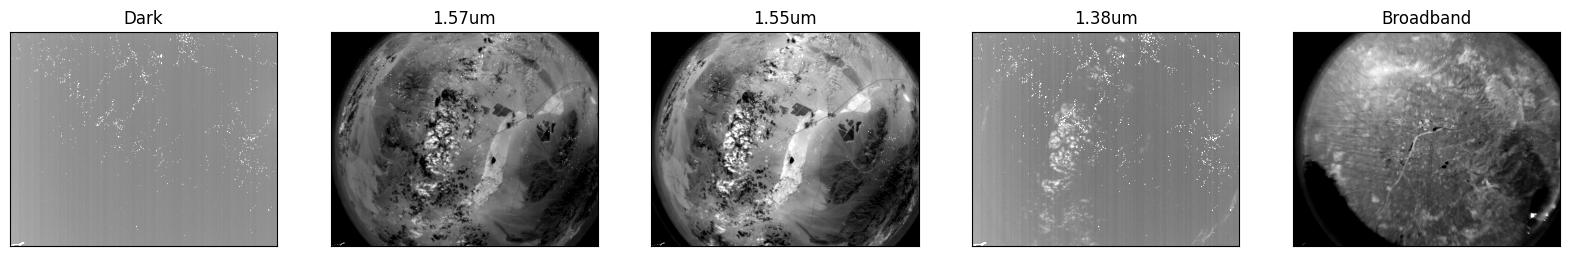

In [120]:
#pos0: dark pos1: 1.57um pos2: 1.55um pos3: 1.38um pos4: bb
filt_name = ['Dark','1.57um','1.55um', '1.38um', 'Broadband']
upper = [3000,5000,5000,2000,8500]
scale = [0,0.2,0.2,0.05,0.3]

plt.figure(figsize=(20,5))
for i in range(5):
    fsort, filt, tec = SWIR_data_meta(str(i))
    plt.subplot(151 + i)
    plt.title(filt_name[i])
    cfc_raw = np.array( Image.open(data_path + f"cfc_capture_{filt[104]}.tiff"),dtype=float )
    cfc_img = (2**14.) - cfc_raw

    if i == 0:
        cfc_dark = cfc_raw
    else:
        cfc_img = cfc_img - cfc_dark*scale[i]

    plt.imshow(cfc_img,clim=[0,upper[i]],cmap = plt.cm.gray)
    #plt.imshow(cfc_img,cmap = plt.cm.gray)
    plt.xticks([])
    plt.yticks([])
    #plt.colorbar()

plt.savefig('./SWIR_examples.png',dpi=300,bbox_inches='tight')

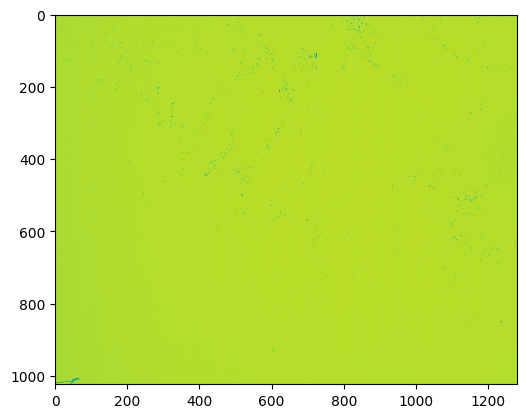

In [72]:
plt.imshow(cfc_dark)

### Create the defect mask for the SWIR pixels

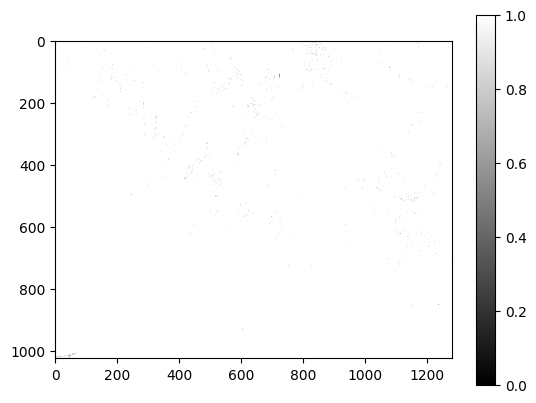

In [4]:
#open imagery
cfc_raw = np.array( Image.open(data_path + f"cfc_capture_{filt[0]}.tiff"),dtype=float )
cfc_img = (2**14) - cfc_raw

#histogram analysis to find hotter pixels
cfc_img[cfc_img > 13000] = np.nan

#make simple mask
cfc_img[~np.isnan(cfc_img)] = 1
cfc_img[cfc_img != 1] = 0

#plot it
plt.imshow(cfc_img,clim=[0,1],cmap = plt.cm.gray)
plt.colorbar()

#save mask to file
cfc_img.astype("float32").tofile("/home/jupyter-bmcbride/AH2_Data_Products/SWIR/SWIRDefectMask.raw")

In [326]:
#glamr file
glamr_path = "/data/ESI/Shared/Data/airHARP2/gsfc_cal_march2025/swir/SWIR_250313/OPO_NIR_Idler.20250313-1stshift.txt"

jd_start, jd_end, wvl, rad = [],[],[],[]
with open(glamr_path, 'r') as file:
    # Read all lines into a list
    lines = file.readlines()

    # Iterate through each line
    for lc, line in enumerate(lines):

        if lc == 0: 
            continue
            
        # Strip whitespace and split the line into parts
        parts = line.strip().split()
        jd_start.append(float(parts[2]))
        jd_end.append(float(parts[3]))
        wvl.append(float(parts[9]))
        rad.append(float(parts[13]))

# filter for 1390 stuff
jd_start, jd_end = np.array(jd_start), np.array(jd_end)
wvl, rad = np.array(wvl),np.array(rad)

loc = np.where( np.array(wvl) < 1450 )[0]

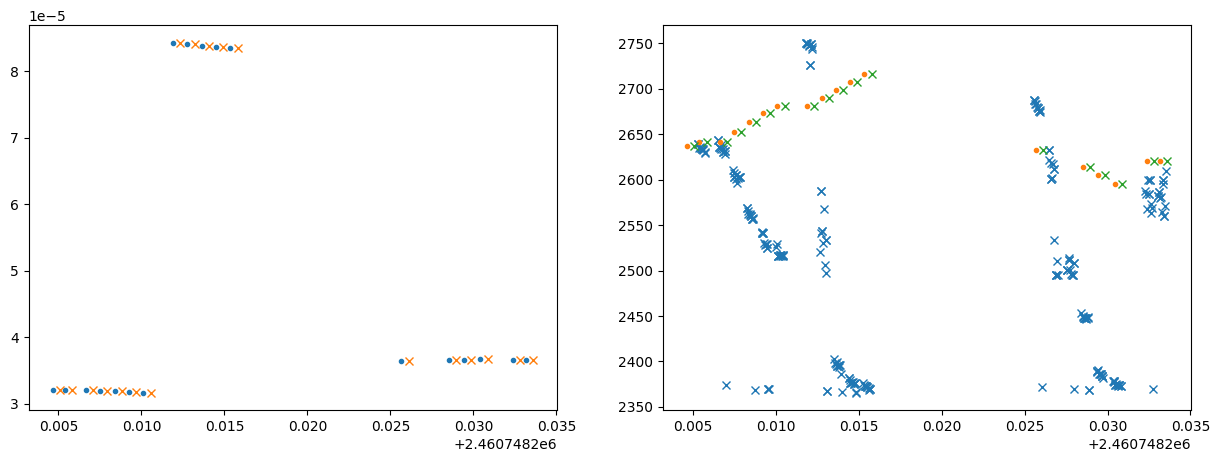

In [345]:
plt.figure(figsize=(15,5))
plt.subplot(121)
plt.plot(jd_start[loc],rad[loc],'.')
plt.plot(jd_end[loc],rad[loc],'x')
plt.subplot(122)
conv = julian + 0.999904*(jd_start[loc][0] - julian[0])
plt.plot(conv,dark_cfc,'x')
f = 1.9
plt.plot(jd_start[loc],wvl[loc]*f,'.')
plt.plot(jd_end[loc],wvl[loc]*f,'x')
#plt.plot(julian[meta_idx],'.')

plt.savefig("./Time_Collocation_GLAMR-SWIR.png",dpi=200,bbox_inches='tight')

In [343]:
from scipy.interpolate import interp1d

int_wvl  = interp1d(jd_end[loc],wvl[loc],kind='slinear')
int_rad  = interp1d(jd_end[loc],rad[loc],kind='slinear')
wvl_to_SWIR = int_wvl(conv)
rad_to_SWIR = int_rad(conv)

Text(0, 0.5, 'Dark-Subtracted Counts/GLAMR Radiance')

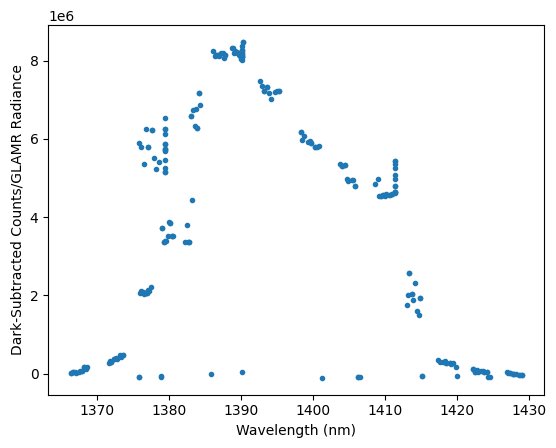

In [344]:
dark_val = 2372.133
plt.plot(wvl_to_SWIR,(np.array(dark_cfc) - dark_val)/rad_to_SWIR,'.')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Dark-Subtracted Counts/GLAMR Radiance")
#plt.xlim(1350,1440)
#plt.savefig("./1390nm_Attempt.png",dpi=200,bbox_inches='tight')

In [347]:
250/4000.

0.0625

### Apply mask to every image read in and save statistics

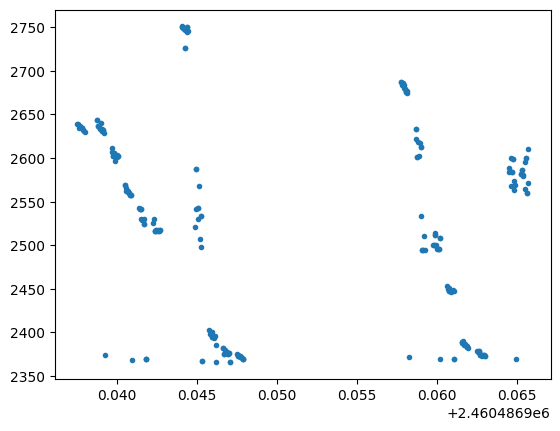

In [341]:
#load in defect mask
# mask = np.fromfile("/home/jupyter-bmcbride/AH2_Data_Products/SWIR/SWIRDefectMask.raw",dtype='float32').reshape([1024,1280])
# mask[mask == 0] = np.nan

#open all imagery for a single filter
dark_cfc = []
meta_idx = []
for vc,v in enumerate(filt):

    check_path = data_path + f"cfc_capture_{v}.tiff"
    #print(check_path, path.exists(check_path))
    
    #load the file and convert
    if path.exists(check_path):
        cfc_raw = np.array( Image.open(check_path) ,dtype=float )
        meta_idx.append(vc)
    else: #some files may not have associated metadata
        print(f"No metadata for {v}.")
        continue
        
    cfc_img = ((2**14)-cfc_raw)#*mask

    #average images
    dark_cfc.append(np.nanmean(cfc_img[500:700,600:800]))

dcfc = []
for vc,v in enumerate(dfilt):

    check_path = data_path + f"cfc_capture_{v}.tiff"
    #print(check_path, path.exists(check_path))
    
    #load the file and convert
    if path.exists(check_path):
        cfc_raw = np.array( Image.open(check_path) ,dtype=float )
        #meta_idx.append(vc)
    else: #some files may not have associated metadata
        #print(f"No metadata for {v}.")
        continue
        
    cfc_img = ((2**14)-cfc_raw)#*mask

    #average images
    dcfc.append(np.nanmean(cfc_img[500:700,600:800]))

dcfc = np.array( dcfc, dtype=float)

plt.plot(julian[meta_idx],dark_cfc,'.')

In [264]:
np.nanmean(dcfc)

2372.1330193548383

/tmp/ipykernel_1042769/1004178084.py:7: RuntimeWarning: invalid value encountered in divide
  patnrm = pattern/np.nanmean(pattern)


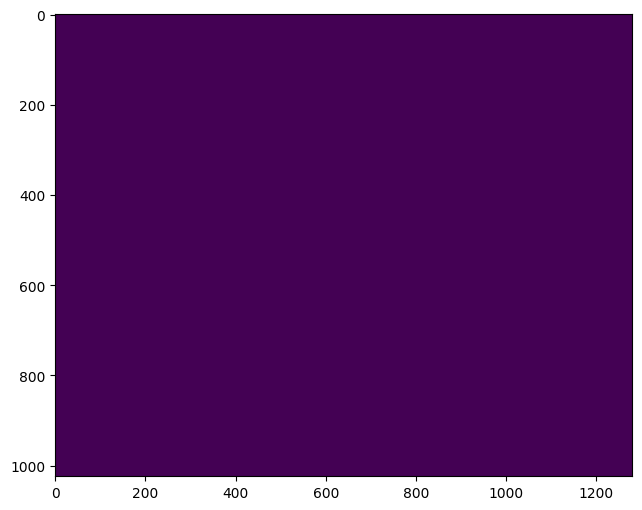

In [34]:
from scipy.signal import savgol_filter
darkavg = np.nanmean(cfc_img,axis=0)
darksmt = savgol_filter(darkavg,300,1)

sys_pat, check = np.meshgrid(darksmt,np.zeros(1024))
pattern = darksmt - sys_pat
patnrm = pattern/np.nanmean(pattern)

plt.figure(1,figsize=(10,6))
# plt.subplot(121)
# plt.plot(darkavg,'k')
# plt.plot(darksmt,'r-')
# plt.subplot(122)
# plt.plot(darksmt - darkavg,'k.')

# plt.figure(2)
plt.imshow(pattern)

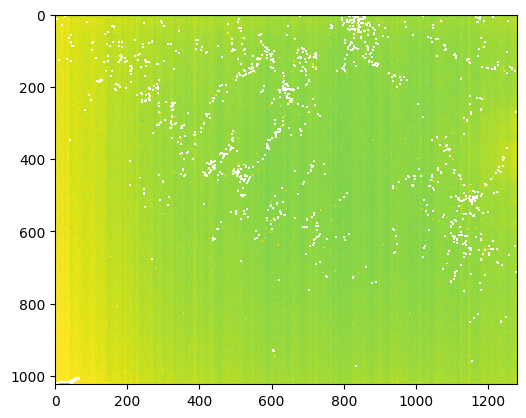

In [104]:
plt.imshow(cfc_img,clim = [0,2000])

## GIF

In [43]:
dn,up = 2000,10000

for j in range(800,900):

    cfc_raw = (2**14) - np.array( Image.open(data_path + f"cfc_capture_{filt[j]}.tiff"),dtype=float )
    
    plt.figure(figsize=(6,6))
    plt.title(filt[j])
    plt.imshow(cfc_raw,clim = [dn,up],cmap = plt.cm.gray)
    plt.yticks([])
    plt.xticks([])
    
    plt.savefig(f'./Figures/SWIR_{filt[j]}.jpg',bbox_inches='tight')
    plt.close()

make_gif('./Figures/')

## Pushbroom

/tmp/ipykernel_1481396/423749134.py:46: RuntimeWarning: Mean of empty slice
  cfc_clean[nany[cnt],nanx[cnt]] = np.nanmean(cfc_raw[nany[cnt]-bn:nany[cnt]+bn,nanx[cnt]-bn:nanx[cnt]+bn])


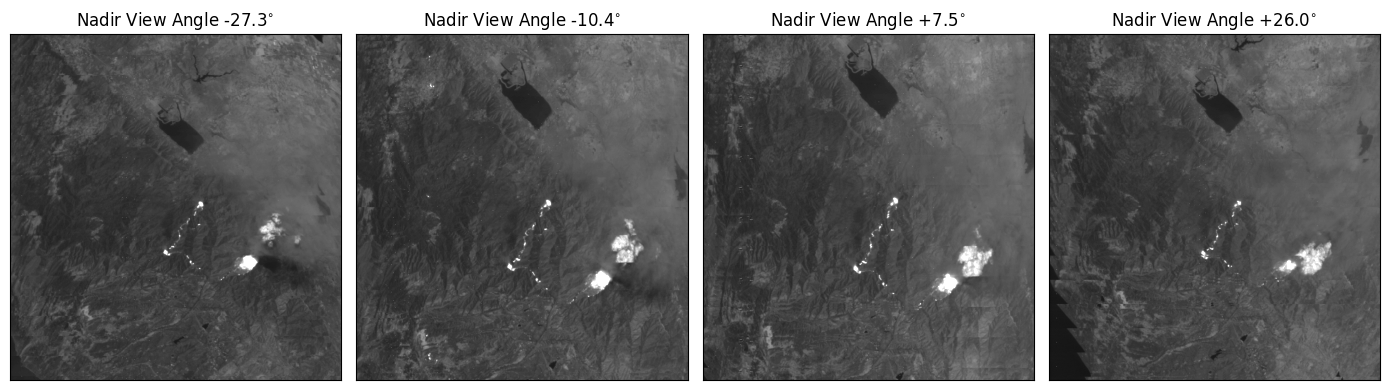

In [212]:
sidx, eidx = 440, 490 #range of images to use
#vsect, vbin = 600,75 #view sector column to parse

#_, filt_1550, _ = SWIR_data_meta('1')
_, filt_1590, _ = SWIR_data_meta('2')
#_, filt_1390, _ = SWIR_data_meta('3')

pushbroom_ang1 = SWIR_pb(sidx, eidx, 400, 58, filt_1590)
pushbroom_ang2 = SWIR_pb(sidx, eidx, 600, 80, filt_1590)
pushbroom_ang3 = SWIR_pb(sidx, eidx, 800, 88, filt_1590)
pushbroom_ang4 = SWIR_pb(sidx, eidx, 1000, 70, filt_1590)

dn,up = 1000,12000
plt.figure(figsize=(14,4))
plt.subplot(141)

# #plt.title(f"Flight image indices {filt[sidx]}-{filt[eidx]}",fontsize=8)
plt.title('Nadir View Angle -27.3$^{\circ}$')
plt.imshow(np.rot90(pushbroom_ang1),clim = [dn,up],cmap = plt.cm.gray,aspect='auto')
plt.ylim(800,1800)

plt.yticks([])
plt.xticks([])

plt.subplot(142)
plt.title('Nadir View Angle -10.4$^{\circ}$')
plt.imshow(np.rot90(pushbroom_ang2),clim = [dn,up],cmap = plt.cm.gray,aspect='auto')
plt.yticks([])
plt.xticks([])
plt.ylim(1500,2500)

plt.subplot(143)
plt.title('Nadir View Angle +7.5$^{\circ}$')
plt.imshow(np.rot90(pushbroom_ang3),clim = [dn,up],cmap = plt.cm.gray,aspect='auto')

plt.yticks([])
plt.xticks([])
plt.ylim(1900,2900)

plt.subplot(144)
plt.title('Nadir View Angle +26.0$^{\circ}$')
plt.imshow(np.rot90(pushbroom_ang4),clim = [dn,up],cmap = plt.cm.gray,aspect='auto')

plt.yticks([])
plt.xticks([])
plt.ylim(1600,2600)

#plt.savefig("./SWIR_pb_2024-09-10_1.55um_4panel.png",dpi=300,bbox_inches='tight')

# plt.subplot(422)
# avg_ = np.nanmean(pushbroom,axis=1)
# avg_n = avg_/np.nanmean(avg_[500:550])
# flat, _ = np.meshgrid(np.ones(3750),avg_n)
# plt.imshow(np.rot90(pushbroom/flat),clim = [dn,up],cmap = plt.cm.gray)

plt.tight_layout()
plt.savefig(f'./SWIR_pushbroom_1.55um_zoom2.png',dpi=300,bbox_inches='tight')
# plt.close()



In [146]:
pushbroom.shape

(1024, 3750)

([], [])

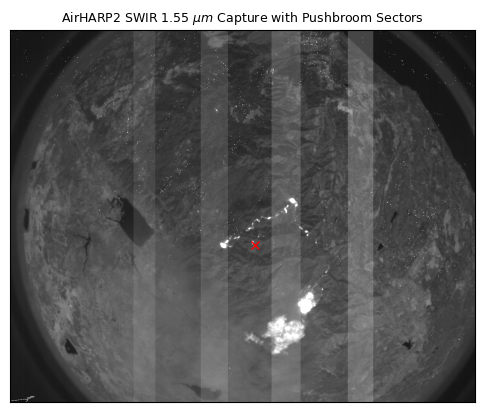

In [145]:
j=465
cfc_raw = (2**14) - np.array( Image.open(data_path + f"cfc_capture_{filt[j]}.tiff"),dtype=float )

plt.figure(figsize=(6,6))
#plt.title(filt[j])
plt.title("AirHARP2 SWIR 1.55 $\mu m$ Capture with Pushbroom Sectors",fontsize=9)
plt.imshow(cfc_raw,clim = [dn,up],cmap = plt.cm.gray)

#sectors
vsect,vbin = [400,600,800,1000],[60,75,80,70]
for i in range(4):
    
    img = np.copy(cfc_raw)
    img[:,vsect[i]-vbin[i]:vsect[i]] = 12000

    plt.imshow(img,clim = [dn,up],cmap=plt.cm.gray,alpha=0.2)
    
plt.plot(674,592,'rx')
#plt.plot(35,592,'bx')
plt.yticks([])
plt.xticks([])

# plt.savefig(f'./Figures/SWIR_{filt[j]}.jpg',bbox_inches='tight')
# plt.close()

0.08966468347366728


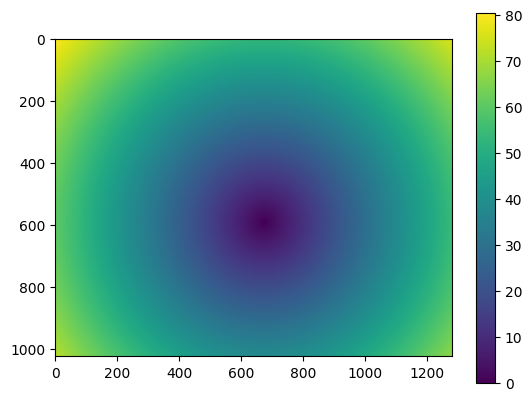

In [105]:
locy,locx = np.where(~np.isinf(cfc_raw))
ceny,cenx = 592,674
nrmy,nrmx = locy - ceny, locx - cenx
ang_ifov = np.arctan( 1/(674-35) )
print(ang_ifov*180/np.pi)
theta = (ang_ifov*180/np.pi*np.sqrt( (locy - ceny)**2 + (locx - cenx)**2 )).reshape([1024,1280])

plt.imshow(theta)
plt.colorbar()


26.04759054910034


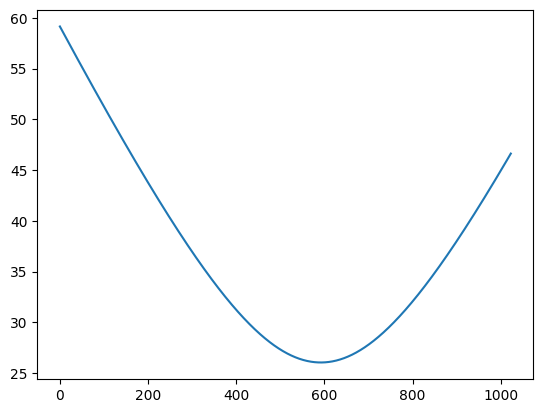

In [121]:
vsect,vbin = 1000, 70
vza = np.nanmean(theta[:,vsect-vbin:vsect],axis=1)
min_vza = np.nanmin(vza)
print(min_vza)
plt.plot(vza)